# Tahap 14 — Seperti apa datanya terlihat

Notebook deskriptif. Ia **tidak menghitung hasil apa pun**, tidak melatih model, dan tidak
menyentuh aturan keputusan. Tujuannya satu: memperlihatkan bentuk data yang dipakai seluruh
skenario, supaya pembaca yang belum pernah melihat tulisan tangan daring punya gambaran konkret
sebelum membaca angka.

Enam pertanyaan dijawab berurutan:

1. Kedua kohort itu isinya apa, dan di mana bedanya
2. Pada UCI 395, apa yang **sebenarnya digambar** subjek
3. Enam kanal yang dilihat model itu seperti apa
4. Pada NewHandPD, kenapa gambarnya **tidak dapat ditampilkan**
5. Berapa panjang rekamannya, dan apa artinya satu patch
6. Di mana pita tremor terlihat, dan siapa yang lebih tua

Seluruhnya berjalan di CPU dari cache pada `data/cache/`.

In [1]:
import sys
sys.path.insert(0, "../src")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch

from preprocessing import muat_cache, NAMA_TUGAS, KANAL_MODEL, FS_TARGET
from newhandpd import muat_cache_bisp, KANAL_MODEL_BISP
from viz import WARNA, TINTA, pasang_gaya, rapikan, pita_tremor

pasang_gaya()
CACHE = Path("../data/cache")
GAMBAR = Path("../figures")
FS = FS_TARGET

uci = muat_cache(CACHE / "uci395_fs100.npz")
nhp = {k: muat_cache_bisp(CACHE / f"newhandpd_{k}_fs100.npz")
       for k in ["spiral", "meander", "dia"]}

print(f"UCI 395    : {len(uci)} rekaman, {len({r.subjek for r in uci})} subjek")
for k, v in nhp.items():
    print(f"NewHandPD {k:8s}: {len(v):4d} rekaman, {len({r.subjek for r in v})} subjek")

UCI 395    : 207 rekaman, 77 subjek
NewHandPD spiral  :  264 rekaman, 66 subjek
NewHandPD meander :  264 rekaman, 66 subjek
NewHandPD dia     :  132 rekaman, 66 subjek


## 1. Dua kohort, sengaja dipilih berjauhan

Pemilihan kedua basis data bukan kebetulan. Keduanya berbeda pada enam sumbu sekaligus, dan itulah
yang membuat replikasi di antara keduanya menjadi ujian yang berarti alih-alih pengulangan.

Perhatikan khususnya dua baris terakhir: **arah komposisi kelasnya terbalik**, dan **NewHandPD tidak
memuat koordinat pena sama sekali**. Yang kedua itu menentukan seluruh rancangan replikasi — tanpa
koordinat, bobot model tidak dapat dipindahkan, sehingga Rumusan Masalah 3 menanyakan replikasi
**metode**, bukan generalisasi model.

In [2]:
def ringkas(rek, nama, perangkat, negara, fs_asli, koordinat):
    subj = {r.subjek for r in rek}
    pd_ = {r.subjek for r in rek if r.kelompok == "PD"}
    hc = {r.subjek for r in rek if r.kelompok == "HC"}
    dur = np.array([len(r.kanal) / FS for r in rek])
    return {"Basis data": nama, "Perangkat": perangkat, "Negara": negara,
            "fs asli": fs_asli, "Rekaman": len(rek), "Subjek": len(subj),
            "PD": len(pd_), "HC": len(hc),
            "Arah kelas": "PD mayoritas" if len(pd_) > len(hc) else "HC mayoritas",
            "Durasi median (s)": round(float(np.median(dur)), 1),
            "Koordinat pena": koordinat}

tabel = pd.DataFrame([
    ringkas(uci, "UCI 395", "tablet digitizer", "Turki", "127,52 Hz", "ada"),
    ringkas(nhp["spiral"], "NewHandPD (spiral)", "smart pen BiSP", "Brasil", "1000 Hz", "TIDAK ADA"),
])
display(tabel.set_index("Basis data").T)

Basis data,UCI 395,NewHandPD (spiral)
Perangkat,tablet digitizer,smart pen BiSP
Negara,Turki,Brasil
fs asli,"127,52 Hz",1000 Hz
Rekaman,207,264
Subjek,77,66
PD,62,31
HC,15,35
Arah kelas,PD mayoritas,HC mayoritas
Durasi median (s),15.6,14.4
Koordinat pena,ada,TIDAK ADA


Enam kanal yang diberikan kepada model juga berbeda sama sekali, dan itu disengaja.

In [3]:
banding = pd.DataFrame({
    "UCI 395 — dari koordinat dan tekanan": KANAL_MODEL,
    "NewHandPD — dari sensor badan pena": KANAL_MODEL_BISP,
})
display(banding)
print("Tidak satu pun kanal yang sama antara kedua kohort.")
print("Yang direplikasi adalah METODE-nya, bukan bobot modelnya.")

,UCI 395 — dari koordinat dan tekanan,NewHandPD — dari sensor badan pena
0,dx,d_mikrofon
1,dy,d_fingergrip
2,kecepatan,d_tekanan
3,percepatan,dd_mikrofon
4,jerk,dd_fingergrip
5,tekanan,dd_tekanan


Tidak satu pun kanal yang sama antara kedua kohort.
Yang direplikasi adalah METODE-nya, bukan bobot modelnya.


## 2. Apa yang sebenarnya digambar

UCI 395 memuat koordinat, sehingga jejak penanya dapat digambar ulang persis seperti yang dilihat
subjek. Tiga tugasnya berbeda sifat:

| Tugas | Isi | Yang tampak |
|---|---|---|
| **SST** | spiral statis — subjek menelusuri spiral yang sudah tercetak | jejak menelusuri |
| **DST** | spiral dinamis — polanya berkedip, subjek menggambar dari ingatan | jejak lebih bebas |
| **STCP** | menahan pena di atas satu titik tanpa menyentuh layar | **tidak ada gambar** — hanya getaran |

Di bawah ini satu subjek penderita berdampingan dengan satu subjek kontrol, pada tugas yang sama.
Perhatikan kekasaran jejaknya, bukan bentuk keseluruhannya.

> **Catatan penamaan, agar tidak salah baca.** Pengenal subjek pada rilis UCI 395 menyesatkan:
> awalan `H_` **bukan** berarti *healthy*. Kelompoknya sebagai berikut — `C_*` sebanyak 15 subjek
> adalah kontrol, sedangkan `H_P000-*` sebanyak 37 subjek dan `P_*` sebanyak 25 subjek keduanya
> penderita. Totalnya 62 penderita dan 15 kontrol, dan tidak ada satu pun subjek yang muncul pada
> dua kelompok. Diperiksa langsung dari cache, bukan diasumsikan dari nama berkas.

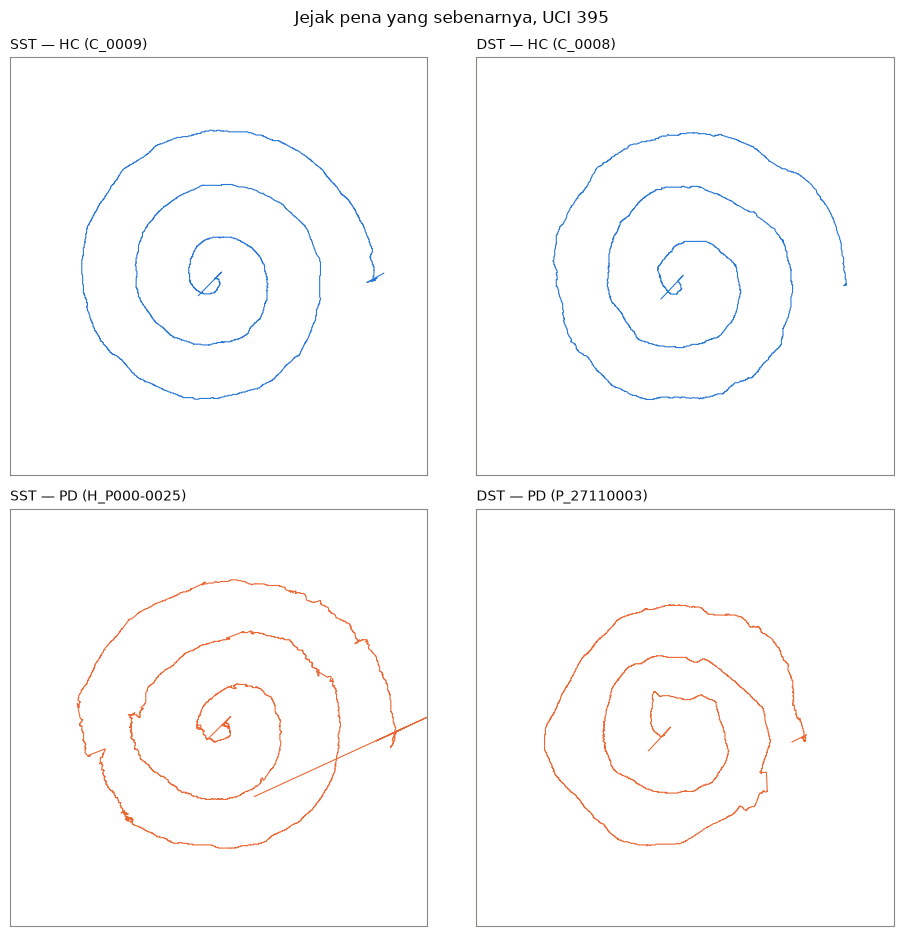

In [4]:
def satu(rek, tugas, kelompok):
    """Ambil rekaman terpanjang milik satu subjek pada tugas dan kelompok tertentu."""
    kandidat = [r for r in rek if r.tugas == tugas and r.kelompok == kelompok
                and r.xy is not None and len(r.xy) > 500]
    return max(kandidat, key=lambda r: len(r.xy)) if kandidat else None

pilih = {(t_, k): satu(uci, t_, k) for t_ in [0, 1] for k in ["HC", "PD"]}
# Batas sumbu disamakan untuk keempat panel supaya ukurannya sebanding dan
# panelnya sama besar; tanpa ini aspect="equal" membuat tiap panel menyusut beda.
jangkau = max(np.abs(r.xy - r.xy.mean(axis=0)).max() for r in pilih.values() if r is not None)

fig, axes = plt.subplots(2, 2, figsize=(9.5, 9.5))
for j, tugas in enumerate([0, 1]):
    for i, kel in enumerate(["HC", "PD"]):
        ax = axes[i, j]
        r = pilih[(tugas, kel)]
        if r is None:
            ax.text(.5, .5, "tidak ada", ha="center", transform=ax.transAxes); continue
        warna = WARNA["biru"] if kel == "HC" else WARNA["jingga"]
        xy = r.xy - r.xy.mean(axis=0)
        ax.plot(xy[:, 0], xy[:, 1], lw=0.8, color=warna)
        ax.set_title(f"{NAMA_TUGAS[tugas]} — {kel} ({r.subjek})", loc="left", fontsize=10)
        ax.set_xlim(-jangkau, jangkau); ax.set_ylim(-jangkau, jangkau)
        ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle("Jejak pena yang sebenarnya, UCI 395", y=0.98, color=TINTA["utama"])
fig.tight_layout()
fig.savefig(GAMBAR / "f14_jejak_pena_uci.png", dpi=150, bbox_inches="tight")
plt.show()

**STCP tidak dapat digambar** sebab penanya ditahan di udara. Yang ada hanya getaran di sekitar
satu titik. Itulah alasan tugas ini menjadi analisis primer: tremor tidak tercampur gerakan yang
disengaja.

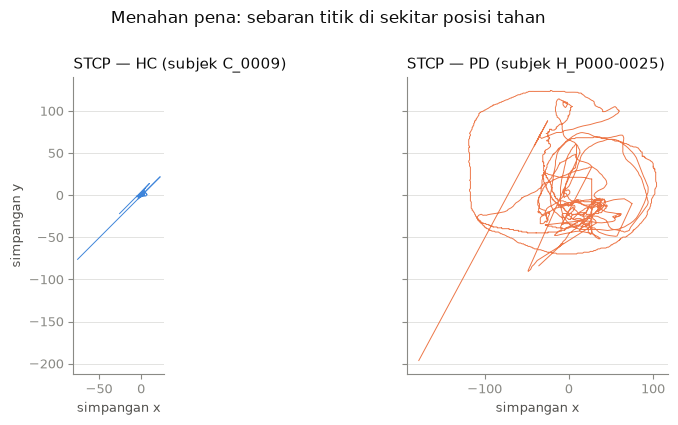

In [5]:
r_pd = satu(uci, 2, "PD"); r_hc = satu(uci, 2, "HC")
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
for ax, r, kel in zip(axes, [r_hc, r_pd], ["HC", "PD"]):
    if r is None: continue
    warna = WARNA["biru"] if kel == "HC" else WARNA["jingga"]
    xy = r.xy - r.xy.mean(axis=0)
    ax.plot(xy[:, 0], xy[:, 1], lw=0.7, color=warna, alpha=0.9)
    ax.set_title(f"STCP — {kel} (subjek {r.subjek})", loc="left")
    ax.set_aspect("equal"); ax.set_xlabel("simpangan x"); rapikan(ax)
axes[0].set_ylabel("simpangan y")
fig.suptitle("Menahan pena: sebaran titik di sekitar posisi tahan", y=1.0, color=TINTA["utama"])
fig.tight_layout()
fig.savefig(GAMBAR / "f14_stcp_sebaran.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Enam kanal yang dilihat model

Model **tidak** menerima koordinat. Ia menerima enam kanal turunan, seluruhnya invarian terhadap
posisi absolut — itulah yang membuat koordinat tetap sah sebagai acuan penanda yang independen.

Satu rekaman ditampilkan utuh di bawah ini, satu kanal per baris.

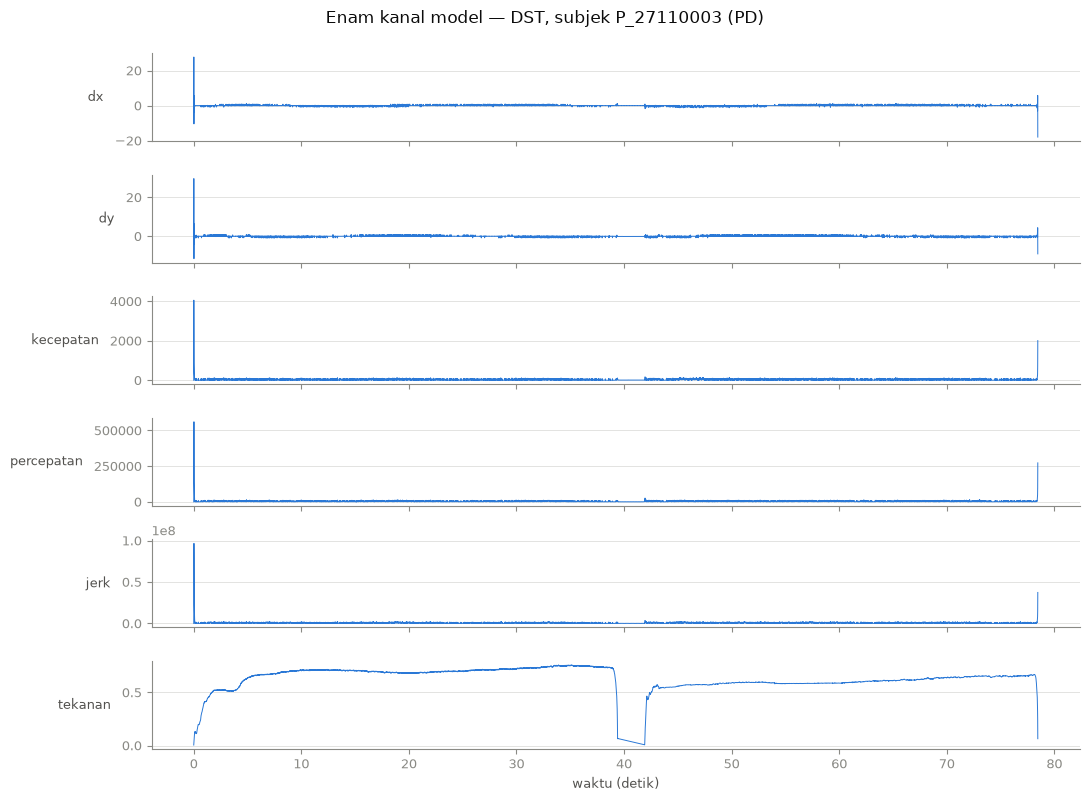

In [6]:
r = satu(uci, 1, "PD")
t = np.arange(len(r.kanal)) / FS
fig, axes = plt.subplots(6, 1, figsize=(11, 8), sharex=True)
for k, (ax, nama) in enumerate(zip(axes, KANAL_MODEL)):
    ax.plot(t, r.kanal[:, k], lw=0.7, color=WARNA["biru"])
    ax.set_ylabel(nama, rotation=0, ha="right", va="center", labelpad=8)
    rapikan(ax)
axes[-1].set_xlabel("waktu (detik)")
fig.suptitle(f"Enam kanal model — {NAMA_TUGAS[r.tugas]}, subjek {r.subjek} ({r.kelompok})",
             y=0.995, color=TINTA["utama"])
fig.tight_layout()
fig.savefig(GAMBAR / "f14_kanal_uci.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. NewHandPD: kenapa gambarnya tidak dapat ditampilkan

Smart pen BiSP tidak merekam posisi. Ia merekam apa yang terjadi **di badan pena**: mikrofon,
cengkeraman jari, tekanan aksial isi pena, serta kemiringan dan percepatan tiga sumbu.

Tidak ada koordinat, sehingga tidak ada jejak yang dapat digambar ulang. Ini bukan kekurangan
melainkan sifat perangkatnya — dan justru itu yang menjadikan kohort ini ujian replikasi yang keras.

Pemisahannya penting dan dipakai seluruh skenario:

- **Kanal 1–3 diberikan kepada model** (mikrofon, fingergrip, tekanan aksial)
- **Kanal 4–6 ditahan sepenuhnya** (tilt dan percepatan) dan hanya dipakai menghitung penanda

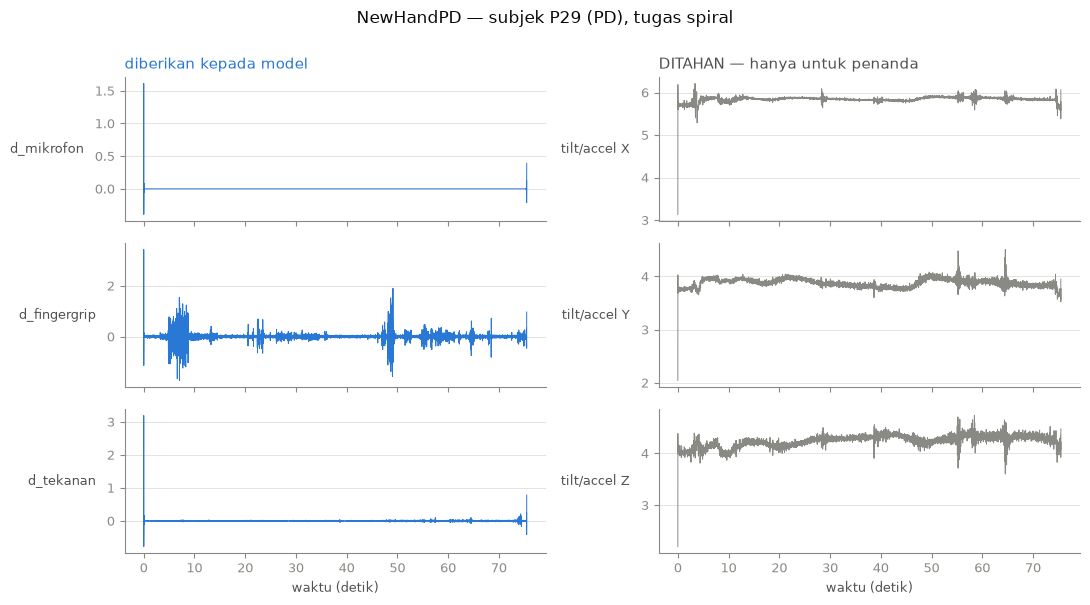

In [7]:
r = max((x for x in nhp["spiral"] if x.kelompok == "PD"), key=lambda x: len(x.kanal))
t = np.arange(len(r.kanal)) / FS
fig, axes = plt.subplots(3, 2, figsize=(11, 6), sharex=True)

for k in range(3):                       # kanal yang DIBERIKAN, sudah jadi beda pertama
    axes[k, 0].plot(t, r.kanal[:, k], lw=0.7, color=WARNA["biru"])
    axes[k, 0].set_ylabel(KANAL_MODEL_BISP[k], rotation=0, ha="right", va="center", labelpad=8)
    rapikan(axes[k, 0])
for k in range(3):                       # kanal yang DITAHAN
    axes[k, 1].plot(t, r.kanal_ditahan[:, k], lw=0.7, color=WARNA["netral"])
    axes[k, 1].set_ylabel(["tilt/accel X", "tilt/accel Y", "tilt/accel Z"][k],
                          rotation=0, ha="right", va="center", labelpad=8)
    rapikan(axes[k, 1])
axes[0, 0].set_title("diberikan kepada model", loc="left", color=WARNA["biru"])
axes[0, 1].set_title("DITAHAN — hanya untuk penanda", loc="left", color=TINTA["sekunder"])
axes[-1, 0].set_xlabel("waktu (detik)"); axes[-1, 1].set_xlabel("waktu (detik)")
fig.suptitle(f"NewHandPD — subjek {r.subjek} ({r.kelompok}), tugas spiral",
             y=1.0, color=TINTA["utama"])
fig.tight_layout()
fig.savefig(GAMBAR / "f14_kanal_newhandpd.png", dpi=150, bbox_inches="tight")
plt.show()

NewHandPD memuat dua belas tugas. Skenario replikasi memakai empat tugas spiral; delapan sisanya
membuka sumbu geser tugas dengan subjek, perangkat, dan negara terkunci konstan.

In [8]:
ringkasan = []
for k, rek in nhp.items():
    dur = np.array([len(x.kanal) / FS for x in rek])
    ringkasan.append({"Keluarga": k, "Rekaman": len(rek),
                      "Subjek": len({x.subjek for x in rek}),
                      "Durasi median (s)": round(float(np.median(dur)), 1),
                      "Durasi min-maks (s)": f"{dur.min():.1f}-{dur.max():.1f}",
                      "Patch pada P=7": int(np.median(dur * FS // 7))})
display(pd.DataFrame(ringkasan).set_index("Keluarga"))

,Rekaman,Subjek,Durasi median (s),Durasi min-maks (s),Patch pada P=7
Keluarga,,,,,
spiral,264,66,14.4,3.2-75.5,205
meander,264,66,12.8,4.9-45.0,181
dia,132,66,22.0,8.2-51.6,314


## 5. Panjang rekaman, dan apa artinya satu patch

Model tidak melihat sampel satu per satu. Ia melihat **patch** — potongan waktu berdurasi tetap.
Konfigurasi beku memakai patch 7, yaitu **70 milidetik** per patch pada 100 Hz.

Angka itu menentukan resolusi seluruh peta temporal: satu bobot atensi berlaku bagi 70 milidetik,
bukan bagi satu titik waktu.

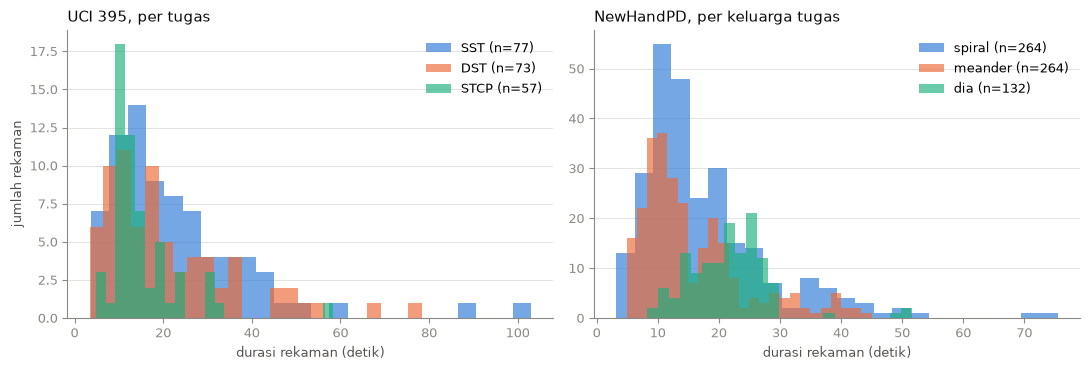

Patch 7 = 70 ms. UCI 395: median 222 patch per rekaman (rentang 48-1472).


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

dur_uci = {NAMA_TUGAS[k]: np.array([len(r.kanal) / FS for r in uci if r.tugas == k])
           for k in sorted({r.tugas for r in uci})}
for (nama, d), w in zip(dur_uci.items(), [WARNA["biru"], WARNA["jingga"], WARNA["toska"]]):
    axes[0].hist(d, bins=24, alpha=0.65, label=f"{nama} (n={len(d)})", color=w)
axes[0].set_xlabel("durasi rekaman (detik)"); axes[0].set_ylabel("jumlah rekaman")
axes[0].set_title("UCI 395, per tugas", loc="left"); axes[0].legend(); rapikan(axes[0])

for (nama, rek), w in zip(nhp.items(), [WARNA["biru"], WARNA["jingga"], WARNA["toska"]]):
    d = np.array([len(x.kanal) / FS for x in rek])
    axes[1].hist(d, bins=24, alpha=0.65, label=f"{nama} (n={len(d)})", color=w)
axes[1].set_xlabel("durasi rekaman (detik)")
axes[1].set_title("NewHandPD, per keluarga tugas", loc="left"); axes[1].legend(); rapikan(axes[1])
fig.tight_layout()
fig.savefig(GAMBAR / "f14_durasi.png", dpi=150, bbox_inches="tight")
plt.show()

P = 7
n_patch = np.array([len(r.kanal) // P for r in uci])
print(f"Patch {P} = {P*10} ms. UCI 395: median {int(np.median(n_patch))} patch per rekaman "
      f"(rentang {n_patch.min()}-{n_patch.max()}).")

Satu rekaman diperbesar di bawah ini, dengan batas patch digambar. Inilah kisi yang dipakai
bobot atensi, atribusi Shapley, dan penanda motorik — ketiganya pada kisi yang sama persis, sebab
kalau tidak, ketiganya tidak dapat dibandingkan.

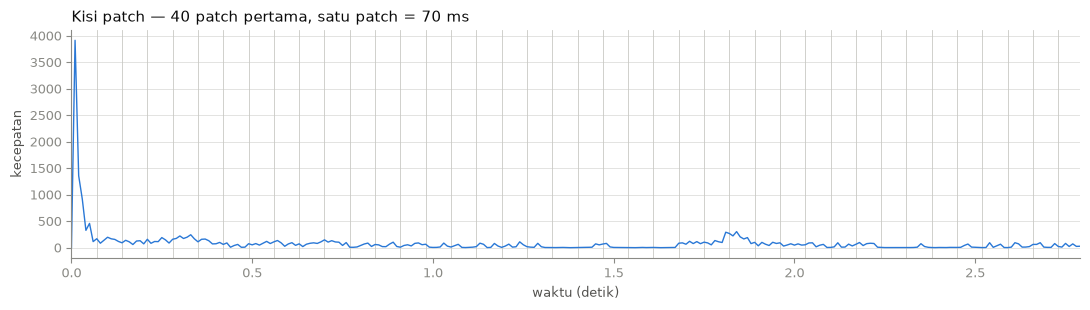

In [10]:
r = satu(uci, 2, "PD")
P, n_tampil = 7, 40
potong = r.kanal[:P * n_tampil, 2]          # kanal kecepatan
t = np.arange(len(potong)) / FS

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(t, potong, lw=1.0, color=WARNA["biru"])
for b in range(n_tampil + 1):
    ax.axvline(b * P / FS, color=WARNA["redup"], lw=0.6, zorder=0)
ax.set_xlabel("waktu (detik)"); ax.set_ylabel("kecepatan")
ax.set_title(f"Kisi patch — {n_tampil} patch pertama, satu patch = {P*10} ms", loc="left")
ax.set_xlim(0, t[-1]); rapikan(ax)
fig.tight_layout()
fig.savefig(GAMBAR / "f14_kisi_patch.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Pita tremor, dan siapa yang lebih tua

**Pita tremor 3,5 sampai 7,5 Hz** dibekukan dari literatur sebelum data hasil dilihat. Kerapatan
spektral daya kanal kecepatan memperlihatkan di mana pita itu berada relatif terhadap gerakan yang
disengaja, yang jauh lebih lambat.

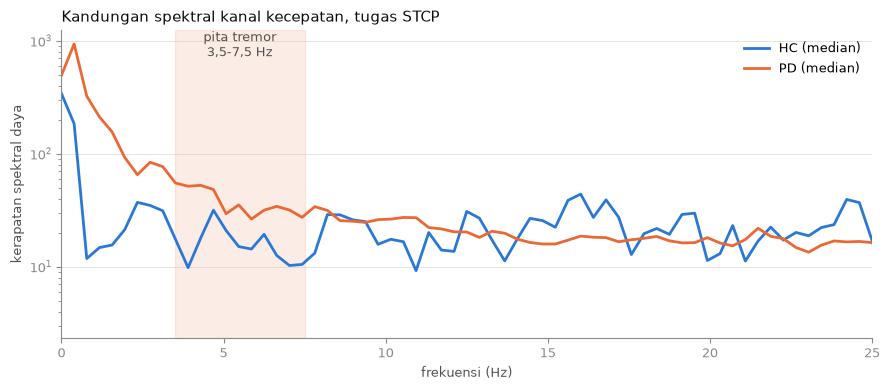

In [11]:
def psd_kelompok(rek, tugas, kel, kanal=2):
    kur = []
    for r in rek:
        if r.tugas != tugas or r.kelompok != kel or len(r.kanal) < 512:
            continue
        f, P_ = welch(r.kanal[:, kanal], fs=FS, nperseg=256)
        kur.append(P_)
    return f, np.median(np.vstack(kur), axis=0)

fig, ax = plt.subplots(figsize=(9, 4))
for kel, w in [("HC", WARNA["biru"]), ("PD", WARNA["jingga"])]:
    f, P_ = psd_kelompok(uci, 2, kel)
    ax.semilogy(f, P_, color=w, label=f"{kel} (median)")
ax.axvspan(*pita_tremor, color=WARNA["jingga"], alpha=0.12, zorder=0)
ax.annotate("pita tremor\n3,5-7,5 Hz", xy=(np.mean(pita_tremor), ax.get_ylim()[1]),
            ha="center", va="top", fontsize=9, color=TINTA["sekunder"])
ax.set_xlim(0, 25); ax.set_xlabel("frekuensi (Hz)"); ax.set_ylabel("kerapatan spektral daya")
ax.set_title("Kandungan spektral kanal kecepatan, tugas STCP", loc="left")
ax.legend(); rapikan(ax)
fig.tight_layout()
fig.savefig(GAMBAR / "f14_spektrum_tremor.png", dpi=150, bbox_inches="tight")
plt.show()

Terakhir, dua sifat komposisi kohort yang harus terlihat sebelum angka mana pun dibaca.

Yang pertama, **arah komposisi kelasnya terbalik** antara kedua basis data. Yang kedua, dan baru
terlihat setelah metadata NewHandPD dibaca: **kelompok penderita jauh lebih tua**. Perancu itu
diaudit tersendiri; di sini ia sekadar ditampilkan.

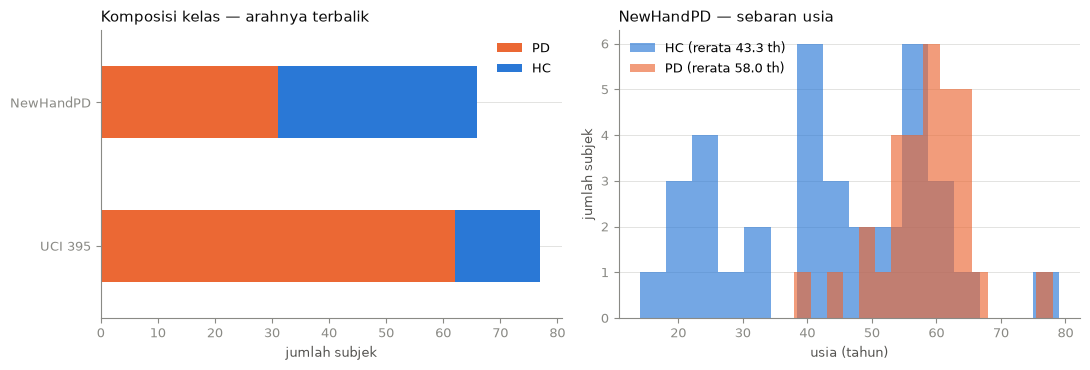

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

komposisi = pd.DataFrame({
    "UCI 395": [len({r.subjek for r in uci if r.kelompok == k}) for k in ["PD", "HC"]],
    "NewHandPD": [len({r.subjek for r in nhp["spiral"] if r.kelompok == k}) for k in ["PD", "HC"]],
}, index=["PD", "HC"])
komposisi.T.plot(kind="barh", stacked=True, ax=axes[0],
                 color=[WARNA["jingga"], WARNA["biru"]])
axes[0].set_xlabel("jumlah subjek")
axes[0].set_title("Komposisi kelas — arahnya terbalik", loc="left")
rapikan(axes[0])

meta = Path("../results/p4_meta_subjek.csv")
if meta.exists():
    m = pd.read_csv(meta)
    m["Age"] = pd.to_numeric(m["Age"], errors="coerce")
    for kel, w in [("HC", WARNA["biru"]), ("PD", WARNA["jingga"])]:
        d = m[m.kelompok == kel].Age.dropna()
        axes[1].hist(d, bins=16, alpha=0.65, color=w, label=f"{kel} (rerata {d.mean():.1f} th)")
    axes[1].set_xlabel("usia (tahun)"); axes[1].set_ylabel("jumlah subjek")
    axes[1].set_title("NewHandPD — sebaran usia", loc="left"); axes[1].legend()
    rapikan(axes[1])
else:
    axes[1].text(.5, .5, "jalankan scripts/analisis_p4_geser_tugas.py --periksa",
                 ha="center", transform=axes[1].transAxes)
fig.tight_layout()
fig.savefig(GAMBAR / "f14_komposisi.png", dpi=150, bbox_inches="tight")
plt.show()

## Ringkas

- Data mentahnya adalah **jejak pena sebagai deret waktu**, bukan citra. Sumbu waktunya nyata dan
  itulah yang dilokalisasi penelitian ini.
- **UCI 395 memuat koordinat, NewHandPD tidak.** Perbedaan itu menentukan bentuk replikasi.
- Model **tidak pernah melihat koordinat** pada kedua kohort. Itulah yang menjaga penanda motorik
  tetap menjadi acuan yang benar-benar independen.
- Satu bobot atensi berlaku bagi **70 milidetik**, bukan bagi satu titik waktu.
- Dua sifat kohort yang harus diingat saat membaca hasil: arah komposisi kelas **terbalik**, dan
  kelompok penderita pada NewHandPD **jauh lebih tua**.

Gambar tersimpan di `figures/f14_*.png`.